In [550]:
import json

import cmasher as cmr
import gc_utils
import h5py
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from astropy.stats import biweight_location
from matplotlib import cm
from matplotlib.animation import PillowWriter
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import LogLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d, zoom
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.stats import binned_statistic_2d

In [ ]:
sim = "m12i"
group_id = 0
disk_form = 6

# about 2 minutes to run on 101 iterations
it_min = 0
it_max = 100

In [552]:
snap_lim = 46
sim_dir = "/Users/z5114326/Documents/simulations/"

pub_data = sim_dir + "snapshot_times_public.txt"
pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
pub_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
snap_lst = pub_snaps["index"].to_numpy()
time_lst = pub_snaps["time_Gyr"].to_numpy()

snap_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["index"].to_numpy()
time_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].to_numpy()

all_data = sim_dir + "/" + sim + "/" + sim + "_res7100/" + "snapshot_times.txt"
all_snaps = pd.read_table(all_data, comment="#", header=None, sep=r"\s+")
all_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
proc_data = h5py.File(proc_file, "r")  # open processed data file

grp_file = sim_dir + sim + "/" + "gc_groups.json"
with open(grp_file, "r") as file:
    grp_dict = json.load(file)

grp_lst = [int(grp) for grp in grp_dict[sim].keys()]
grp_lst

[0, 1920378, 4414957, 8580896, 13687078, 16199669, 19898495]

In [553]:
if group_id not in grp_lst:
    raise ValueError(f"group_id {group_id} not found in grp_lst")

The Following is set up for the plots to be shown below. No need to rerun this for each variable. Scroll down to change variable for plotting

In [554]:
it_dict = {gc_utils.iteration_name(it): {} for it in range(it_min, it_max + 1)}

for it_id in it_dict.keys():
    src_dat = proc_data[it_id]["source"]
    ana_msk = src_dat["analyse_flag"][()] == 1
    grp_msk_src = src_dat["group_id"][()] == group_id

    snp_dat_600 = proc_data[it_id]["snapshots"]["snap600"]
    grp_msk_600 = snp_dat_600["group_id"][()] == group_id
    gc_sur_lst = snp_dat_600["gc_id"][grp_msk_600]

    gc_dict = {gcid: {} for gcid in gc_sur_lst}

    for gcid in gc_dict.keys():
        gcid_idx = np.where(src_dat["gc_id"][ana_msk & grp_msk_src] == gcid)[0][0]
        if group_id == 0:
            tform = src_dat["form_time"][ana_msk & grp_msk_src][gcid_idx]
        else:
            tform = src_dat["t_acc"][ana_msk & grp_msk_src][gcid_idx]
        gc_dict[gcid]["tform"] = tform

    it_dict[it_id] = gc_dict

tform_all = []
for it_id in it_dict.keys():
    for gcid in it_dict[it_id].keys():
        tform_all.append(it_dict[it_id][gcid]["tform"])
tform_unq = np.unique(np.array(tform_all))

if group_id == 0:
    tform_bins = 6
else:
    tform_bins = 1

vmin, vmax = np.min(tform_unq), np.max(tform_unq)
bin_edges = np.linspace(vmin, vmax, tform_bins + 1)
bin_indices = np.digitize(tform_unq, bin_edges, right=False) - 1
bin_indices[bin_indices == tform_bins] = tform_bins - 1

# for i in range(tform_bins):
#     bin_vals = tform_unq[bin_indices == i]
#     print(f"Bin {i + 1}:")
#     print(f"  Time range: {bin_edges[i]:.3f} to {bin_edges[i + 1]:.3f}")
#     print(f"  Count: {len(bin_vals)}")
#     print(f"  Values: {np.round(bin_vals, 3)}\n")

tform_to_bin = {t: b for t, b in zip(tform_unq, bin_indices)}

for it_id in it_dict.keys():
    for gcid in it_dict[it_id].keys():
        tform = it_dict[it_id][gcid]["tform"]
        tform_grp = tform_to_bin[tform]
        it_dict[it_id][gcid]["tform_grp"] = tform_grp

# Initialize bin counts
tform_bin_cnts = {i: 0 for i in range(tform_bins)}

# Count how many GCs are in each tform_grp
for it_id in it_dict.keys():
    for gcid in it_dict[it_id].keys():
        grp = it_dict[it_id][gcid]["tform_grp"]
        tform_bin_cnts[grp] += 1

# Print the counts
print("GC counts per tform_grp bin:")
for i in range(tform_bins):
    print(f"  Bin {i} ({bin_edges[i]:.3f} – {bin_edges[i + 1]:.3f}): {tform_bin_cnts[i]} GCs")

# for it_id in it_dict.keys():
#     for gcid in it_dict[it_id].keys():
#         tform_grp = np.where(tform_unq == it_dict[it_id][gcid]["tform"])[0][0]
#         it_dict[it_id][gcid]["tform_grp"] = tform_grp

GC counts per tform_grp bin:
  Bin 0 (0.848 – 1.551): 170 GCs
  Bin 1 (1.551 – 2.253): 4054 GCs
  Bin 2 (2.253 – 2.955): 2091 GCs
  Bin 3 (2.955 – 3.658): 1756 GCs
  Bin 4 (3.658 – 4.360): 1959 GCs
  Bin 5 (4.360 – 5.063): 2628 GCs


In [555]:
for it_id in it_dict.keys():
    for gcid in it_dict[it_id].keys():
        it_dict[it_id][gcid]["et_norm"] = []
        it_dict[it_id][gcid]["jr"] = []
        it_dict[it_id][gcid]["jp"] = []
        it_dict[it_id][gcid]["jz"] = []


for it_id in it_dict.keys():
    for snap in snap_lst:
        snap_id = gc_utils.snapshot_name(snap)

        snp_dat = proc_data[it_id]["snapshots"][snap_id]
        acc_msk = snp_dat["now_accreted"][()] == 1
        grp_msk = snp_dat["group_id"][()] == group_id

        gc_snp_lst = snp_dat["gc_id"][acc_msk & grp_msk]

        for gcid in it_dict[it_id].keys():
            if gcid not in gc_snp_lst:
                it_dict[it_id][gcid]["et_norm"].append(0)
                it_dict[it_id][gcid]["jr"].append(0)
                it_dict[it_id][gcid]["jp"].append(0)
                it_dict[it_id][gcid]["jz"].append(0)

            else:
                gcid_idx = np.where(snp_dat["gc_id"][acc_msk & grp_msk] == gcid)[0][0]
                et_norm = snp_dat["et_norm"][acc_msk & grp_msk][gcid_idx]
                j_cyl = snp_dat["j.cyl"][acc_msk & grp_msk][gcid_idx]

                it_dict[it_id][gcid]["et_norm"].append(et_norm)
                it_dict[it_id][gcid]["jr"].append(j_cyl[0])
                it_dict[it_id][gcid]["jp"].append(j_cyl[1])
                it_dict[it_id][gcid]["jz"].append(j_cyl[2])

for it_id in it_dict.keys():
    for gcid in it_dict[it_id].keys():
        it_dict[it_id][gcid]["det_norm"] = np.diff(it_dict[it_id][gcid]["et_norm"])
        it_dict[it_id][gcid]["djr"] = np.diff(it_dict[it_id][gcid]["jr"])
        it_dict[it_id][gcid]["djp"] = np.diff(it_dict[it_id][gcid]["jp"])
        it_dict[it_id][gcid]["djz"] = np.diff(it_dict[it_id][gcid]["jz"])

        all_zeros = not np.any(it_dict[it_id][gcid]["det_norm"])
        if all_zeros:
            it_dict[it_id][gcid]["det_norm_path"] = np.nan
            it_dict[it_id][gcid]["det_norm_net"] = np.nan

            it_dict[it_id][gcid]["djr_path"] = np.nan
            it_dict[it_id][gcid]["djr_net"] = np.nan

            it_dict[it_id][gcid]["djp_path"] = np.nan
            it_dict[it_id][gcid]["djp_net"] = np.nan

            it_dict[it_id][gcid]["djz_path"] = np.nan
            it_dict[it_id][gcid]["djz_net"] = np.nan

            it_dict[it_id][gcid]["first_term"] = 0
            it_dict[it_id][gcid]["last_term"] = 0
            continue

        first_term_idx = np.min(np.nonzero(it_dict[it_id][gcid]["et_norm"]))
        last_term_idx = np.max(np.nonzero(it_dict[it_id][gcid]["et_norm"]))

        it_dict[it_id][gcid]["det_norm"][first_term_idx - 1] = 0
        it_dict[it_id][gcid]["djr"][first_term_idx - 1] = 0
        it_dict[it_id][gcid]["djp"][first_term_idx - 1] = 0
        it_dict[it_id][gcid]["djz"][first_term_idx - 1] = 0

        # if GC does not survive to z = 0
        # this just here as an ensurance as by selection they survive to z = 0
        if last_term_idx < len(it_dict[it_id][gcid]["det_norm"]) - 1:
            it_dict[it_id][gcid]["det_norm"][last_term_idx] = 0
            it_dict[it_id][gcid]["djr"][last_term_idx] = 0
            it_dict[it_id][gcid]["djp"][last_term_idx] = 0
            it_dict[it_id][gcid]["djz"][last_term_idx] = 0

        det_norm_net = (
            it_dict[it_id][gcid]["et_norm"][last_term_idx] - it_dict[it_id][gcid]["et_norm"][first_term_idx]
        )
        djr_net = it_dict[it_id][gcid]["jr"][last_term_idx] - it_dict[it_id][gcid]["jr"][first_term_idx]
        djp_net = it_dict[it_id][gcid]["jp"][last_term_idx] - it_dict[it_id][gcid]["jp"][first_term_idx]
        djz_net = it_dict[it_id][gcid]["jz"][last_term_idx] - it_dict[it_id][gcid]["jz"][first_term_idx]

        it_dict[it_id][gcid]["det_norm_path"] = np.sum(np.abs(it_dict[it_id][gcid]["det_norm"]))
        it_dict[it_id][gcid]["det_norm_net"] = np.abs(det_norm_net)

        it_dict[it_id][gcid]["djr_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djr"]))
        it_dict[it_id][gcid]["djr_net"] = np.abs(djr_net)

        it_dict[it_id][gcid]["djp_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djp"]))
        it_dict[it_id][gcid]["djp_net"] = np.abs(djp_net)

        it_dict[it_id][gcid]["djz_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djz"]))
        it_dict[it_id][gcid]["djz_net"] = np.abs(djz_net)

        it_dict[it_id][gcid]["first_term"] = first_term_idx
        it_dict[it_id][gcid]["last_term"] = last_term_idx

# Plotting

In [564]:
var = "jr"  # et_norm, jr, jp, jz

(-1975.0, 1975.0)

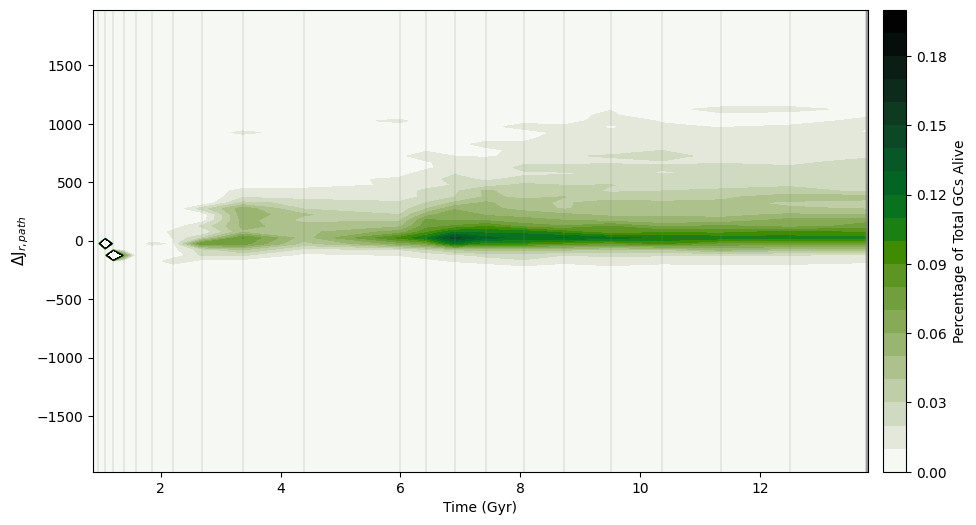

In [565]:
var_dict = {
    "et_norm": {"d_max": 1.5, "d_bin": 0.1, "vmax": 1, "vsize": 0.05, "label": r"$\Delta$e$_{path}$"},
    "jr": {"d_max": 2000, "d_bin": 50, "vmax": 0.2, "vsize": 0.01, "label": r"$\Delta$J$_{r, path}$"},
    "jp": {"d_max": 2000, "d_bin": 50, "vmax": 0.2, "vsize": 0.01, "label": r"$\Delta$J$_{p, path}$"},
    "jz": {"d_max": 2000, "d_bin": 50, "vmax": 0.2, "vsize": 0.01, "label": r"$\Delta$J$_{z, path}$"},
}

d_max = var_dict[var]["d_max"]

# --- SETUP ---
n_snaps = len(pub_snaps[pub_snaps["index"] >= snap_lim])  # number of snapshots >= snap_lim
d_bin_size = var_dict[var]["d_bin"]
d_bins = np.arange(-d_max, d_max + d_bin_size, d_bin_size)
d_centres_in = 0.5 * (d_bins[:-1] + d_bins[1:])
d_bin_num = len(d_bins) - 1

# Arrays to store normalized counts per bin
d_bin_cnt = np.zeros((n_snaps, d_bin_num))

# Loop through snapshots
k = 0
for i, snap in enumerate(snap_lst):
    snap_id = gc_utils.snapshot_name(snap)
    time = pub_snaps[pub_snaps["index"] == snap]["time_Gyr"].values[0]

    # --- COLLECT dvar for ALL GCs alive at this time ---
    d_path_lst = []
    for it_id in it_dict:
        for gcid in it_dict[it_id]:
            if it_dict[it_id][gcid]["tform"] <= time:
                d_arr = it_dict[it_id][gcid]["d" + var]
                d_val = np.nansum(d_arr[: i - 1]) if i >= 2 else 0.0
                d_path_lst.append(d_val)

    d_path_lst = np.array(d_path_lst)
    d_tot = len(d_path_lst)

    # --- BINNING ---
    for j in range(d_bin_num):
        d_min = d_bins[j]
        d_max = d_bins[j + 1]

        d_msk = (d_path_lst >= d_min) & (d_path_lst < d_max)
        z_msk = d_path_lst != 0  # optional: exclude zero change
        d_cnt = np.sum(d_msk & z_msk)

        if d_tot > 0:
            d_bin_cnt[k, j] += d_cnt / d_tot

    k += 1

# --- PLOTTING ---
x = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].to_numpy()
y = d_centres_in
vmin = 0
vmax = var_dict[var]["vmax"]
vsize = var_dict[var]["vsize"]
cmap = cmr.jungle_r
levels = np.arange(vmin, vmax + vsize, vsize)

fig, ax = plt.subplots(figsize=(10, 6))
contour_mig = ax.contourf(x, y, d_bin_cnt.T, cmap=cmap, levels=levels)

# Colorbar
cax = inset_axes(
    ax,
    width="3%",
    height="100%",
    loc="center right",
    bbox_to_anchor=(0.05, 0, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)
cbar = fig.colorbar(contour_mig, cax=cax, orientation="vertical", label="Percentage of Total GCs Alive")
cbar.update_ticks()

# Labels
ax.set_xlabel("Time (Gyr)", fontsize=10)
ax.set_ylabel(var_dict[var]["label"], fontsize=11)

# Vertical time lines
for xi in x:
    ax.plot([xi, xi], [-d_max, d_max], c="grey", lw=0.2)

ax.set_ylim(-(d_max - d_bin_size / 2), d_max - d_bin_size / 2)


(0.0, 4975.0)

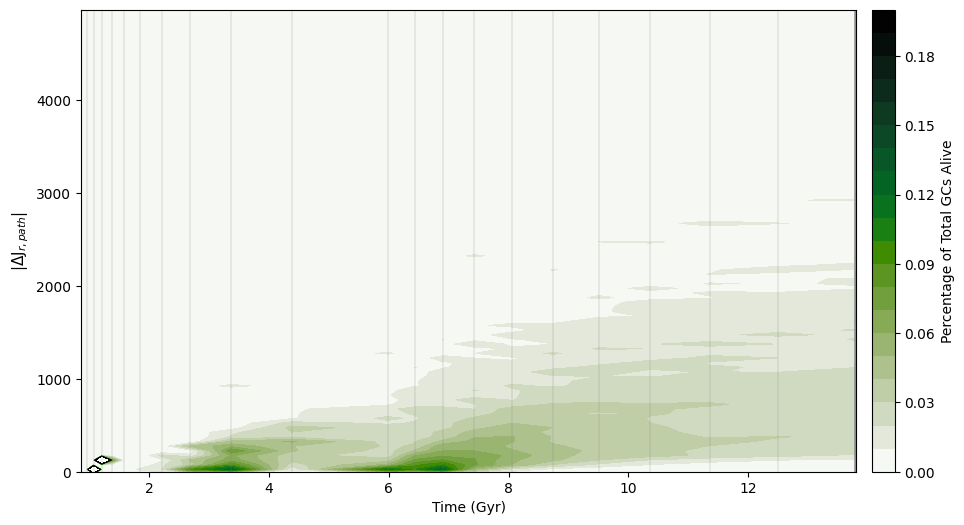

In [566]:
var_dict = {
    "et_norm": {"d_max": 1.5, "d_bin": 0.1, "vmax": 1, "vsize": 0.05, "label": r"|$\Delta$e$_{path}$|"},
    "jr": {"d_max": 5000, "d_bin": 50, "vmax": 0.2, "vsize": 0.01, "label": r"|$\Delta$J$_{r, path}$|"},
    "jp": {"d_max": 5000, "d_bin": 50, "vmax": 0.2, "vsize": 0.01, "label": r"|$\Delta$J$_{p, path}$|"},
    "jz": {"d_max": 5000, "d_bin": 50, "vmax": 0.3, "vsize": 0.01, "label": r"|$\Delta$J$_{z, path}$|"},
}

d_max = var_dict[var]["d_max"]

# --- SETUP ---
n_snaps = len(pub_snaps[pub_snaps["index"] >= snap_lim])  # number of snapshots >= snap_lim
d_bin_size = var_dict[var]["d_bin"]
d_bins = np.arange(-d_max, d_max + d_bin_size, d_bin_size)
d_centres_in = 0.5 * (d_bins[:-1] + d_bins[1:])
d_bin_num = len(d_bins) - 1

# Arrays to store normalized counts per bin
d_bin_cnt = np.zeros((n_snaps, d_bin_num))

# Loop through snapshots
k = 0
for i, snap in enumerate(snap_lst):
    snap_id = gc_utils.snapshot_name(snap)
    time = pub_snaps[pub_snaps["index"] == snap]["time_Gyr"].values[0]

    # --- COLLECT dvar for ALL GCs alive at this time ---
    d_path_lst = []
    for it_id in it_dict:
        for gcid in it_dict[it_id]:
            if it_dict[it_id][gcid]["tform"] <= time:
                d_arr = it_dict[it_id][gcid]["d" + var]
                d_val = np.nansum(np.abs(d_arr[: i - 1])) if i >= 2 else 0.0
                d_path_lst.append(d_val)

    d_path_lst = np.array(d_path_lst)
    d_tot = len(d_path_lst)

    # --- BINNING ---
    for j in range(d_bin_num):
        d_min = d_bins[j]
        d_max = d_bins[j + 1]

        d_msk = (d_path_lst >= d_min) & (d_path_lst < d_max)
        z_msk = d_path_lst != 0  # optional: exclude zero change
        d_cnt = np.sum(d_msk & z_msk)

        if d_tot > 0:
            d_bin_cnt[k, j] += d_cnt / d_tot

    k += 1

# --- PLOTTING ---
x = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].to_numpy()
y = d_centres_in
vmin = 0
vmax = var_dict[var]["vmax"]
vsize = var_dict[var]["vsize"]
cmap = cmr.jungle_r
levels = np.arange(vmin, vmax + vsize, vsize)

fig, ax = plt.subplots(figsize=(10, 6))
contour_mig = ax.contourf(x, y, d_bin_cnt.T, cmap=cmap, levels=levels)

# Colorbar
cax = inset_axes(
    ax,
    width="3%",
    height="100%",
    loc="center right",
    bbox_to_anchor=(0.05, 0, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)
cbar = fig.colorbar(contour_mig, cax=cax, orientation="vertical", label="Percentage of Total GCs Alive")
cbar.update_ticks()

# Labels
ax.set_xlabel("Time (Gyr)", fontsize=10)
ax.set_ylabel(var_dict[var]["label"], fontsize=11)

# Vertical time lines
for xi in x:
    ax.plot([xi, xi], [-d_max, d_max], c="grey", lw=0.2)

ax.set_ylim(0, d_max - d_bin_size / 2)

(0.0, 12000.0)

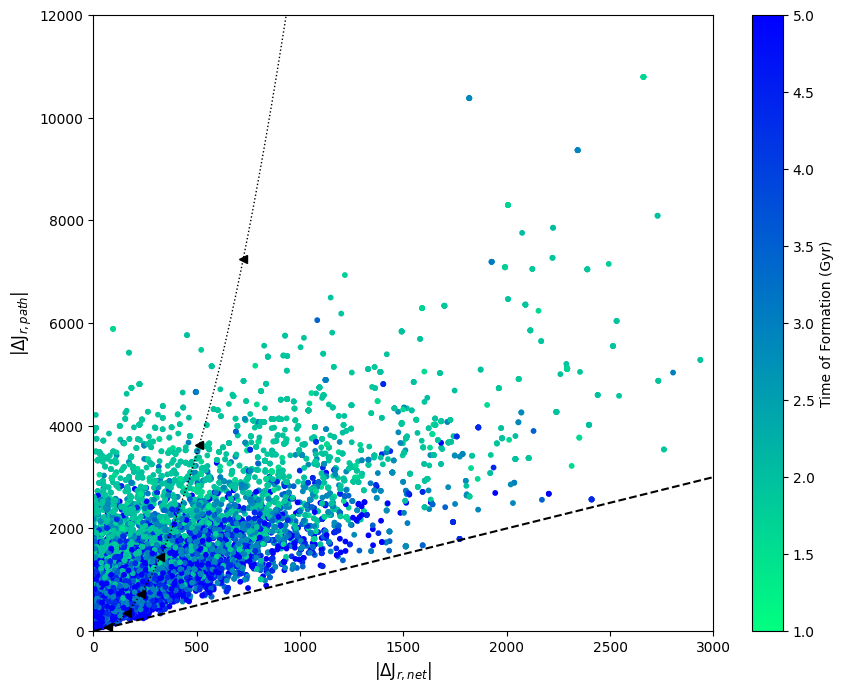

In [567]:
by_age = True

var_dict = {
    "et_norm": {
        "xlab": r"|$\Delta$e$_{net}|$",
        "ylab": r"|$\Delta$e$_{path}|$",
        "xlim": 1,
        "ylim": 2,
    },
    "jr": {
        "xlab": r"|$\Delta$J$_{r, net}|$",
        "ylab": r"|$\Delta$J$_{r, path}|$",
        "xlim": 3000,
        "ylim": 12000,
    },
    "jp": {
        "xlab": r"|$\Delta J_{\phi,\ \mathrm{net}}$|",
        "ylab": r"|$\Delta J_{\phi,\ \mathrm{path}}$|",
        "xlim": 2500,
        "ylim": 10000,
    },
    "jz": {
        "xlab": r"|$\Delta$J$_{z, net}|$",
        "ylab": r"|$\Delta$J$_{z, path}|$",
        "xlim": 2000,
        "ylim": 12000,
    },
}


plt.figure(figsize=(10, 8))

if not by_age:
    cmap = mpl.colormaps["winter_r"]
    col = cmap(0)
    for it_id in it_dict:
        for gcid in it_dict[it_id].keys():
            x = it_dict[it_id][gcid]["d" + var + "_net"]
            y = it_dict[it_id][gcid]["d" + var + "_path"]

            plt.scatter(x, y, c=col, s=10)

    plt.legend()

else:
    cmap = "winter_r"
    vmin = 1
    vmax = 5
    for it_id in it_dict:
        x_lst = []
        y_lst = []
        c_lst = []
        for gcid in it_dict[it_id]:
            x_lst.append(it_dict[it_id][gcid]["d" + var + "_net"])
            y_lst.append(it_dict[it_id][gcid]["d" + var + "_path"])
            c_lst.append(it_dict[it_id][gcid]["tform"])

        plt.scatter(x_lst, y_lst, c=c_lst, s=10, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(label="Time of Formation (Gyr)")

gc_step_dist = []
num_steps = len(snap_lst) - 1
for it_id in it_dict:
    for gcid in it_dict[it_id]:
        # gc_path = gc_dict[gcid]["d" + var + "_path"]
        # gc_step_dist.append(gc_path)

        gc_delta = np.array(it_dict[it_id][gcid]["d" + var])
        gc_step = np.abs(gc_delta[gc_delta != 0])
        gc_step = gc_step[np.isfinite(gc_step)]
        gc_step_dist = np.concatenate((gc_step_dist, gc_step))

# step_size = np.mean(gc_step_dist) / num_steps
step_size = np.mean(gc_step_dist)
# step_size = np.median(gc_step_dist)

walk_steps = 1000
gc_path_1D = [step_size * n for n in range(walk_steps)]
gc_net_1D = [step_size * np.sqrt(n) for n in range(walk_steps)]

n_lst = np.array([1, 5, 10, 20, 50, 100])
plt.plot(gc_net_1D, gc_path_1D, c="k", ls="dotted", lw=1)
plt.plot(step_size * np.sqrt(n_lst), step_size * n_lst, c="k", ls="", lw=1, marker="<", markersize=6)


xlim = var_dict[var]["xlim"]
ylim = var_dict[var]["ylim"]

max_val = np.max([xlim, ylim])

plt.plot([0, max_val], [0, max_val], c="k", ls="--")
plt.xlabel(var_dict[var]["xlab"], fontsize=12)
plt.ylabel(var_dict[var]["ylab"], fontsize=12)

plt.xlim([0, xlim])
plt.ylim([0, ylim])

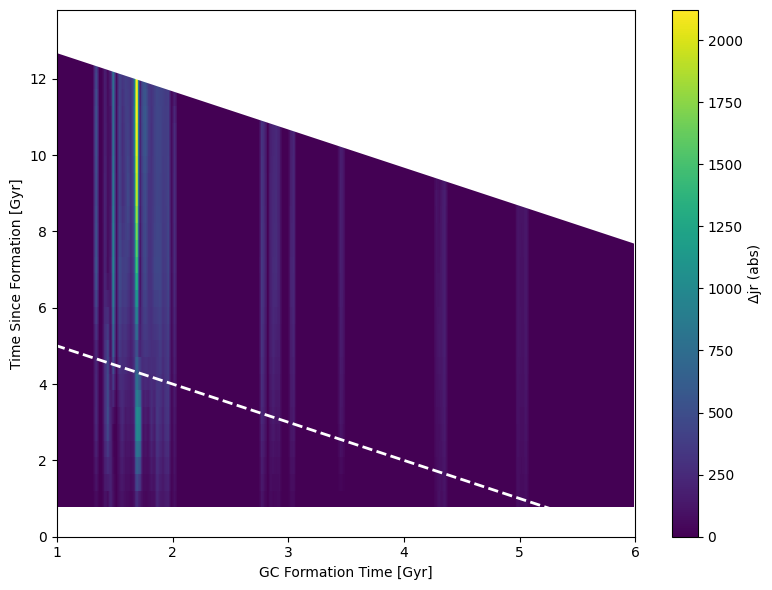

In [568]:
# SETTINGS
plot_type = "abs"
square = False
cmap = "viridis"
line_cut_offset = 0.1

# Containers
tform_all, delta_t_all, d_var_all = [], [], []

# LOOP THROUGH GCs
for it_id in it_dict.keys():
    for gcid in it_dict[it_id].keys():
        tform = it_dict[it_id][gcid]["tform"]
        delta_t = (pub_snaps[pub_snaps["time_Gyr"] >= tform]["time_Gyr"].to_numpy() - tform)[1:]
        f_term = it_dict[it_id][gcid]["first_term"]
        l_term = it_dict[it_id][gcid]["last_term"]

        for i, dt in zip(range(f_term, l_term), delta_t):
            val_now = it_dict[it_id][gcid][var][i + 1]
            val_init = it_dict[it_id][gcid][var][f_term]

            abs_var = np.abs(val_now - val_init)
            del_var = abs_var / np.abs(val_init) if plot_type == "rel" else abs_var
            if square:
                del_var = del_var**2

            tform_all.append(tform)
            delta_t_all.append(dt)
            d_var_all.append(del_var)

# Convert to arrays
tform_all = np.array(tform_all)
delta_t_all = np.array(delta_t_all)
d_var_all = np.array(d_var_all)

# BINNING
xbins = np.linspace(1, disk_form, 200)
ybins = np.linspace(0, np.max(pub_snaps["time_Gyr"]), 8)

stat, xedges, yedges, _ = binned_statistic_2d(
    tform_all, delta_t_all, d_var_all, statistic="median", bins=[xbins, ybins]
)

# REPLACE NaNs with zero (so masked region is clearly zero-valued)
stat = np.nan_to_num(stat, nan=0.0)

# INTERPOLATE
zoom_factor = 4
interp_stat = zoom(stat, zoom_factor, order=1)

# INTERPOLATED AXES
x_centers = 0.5 * (xedges[:-1] + xedges[1:])
y_centers = 0.5 * (yedges[:-1] + yedges[1:])
x_interp = np.linspace(x_centers.min(), x_centers.max(), interp_stat.shape[0])
y_interp = np.linspace(y_centers.min(), y_centers.max(), interp_stat.shape[1])

# MASK ABOVE y = -x + max_time
X, Y = np.meshgrid(x_interp, y_interp, indexing="ij")
max_time = np.max(pub_snaps["time_Gyr"])
mask = Y > (-X + max_time + line_cut_offset)
interp_stat_masked = np.where(mask, np.nan, interp_stat)

# PLOT
plt.figure(figsize=(8, 6))
plt.pcolormesh(x_interp, y_interp, interp_stat_masked.T, shading="auto", cmap=cmap)
plt.colorbar(label=f"Δ{var} ({'rel' if plot_type == 'rel' else 'abs'})")

# Diagonal cutoff line
plt.plot([0, max_time], [max_time + line_cut_offset, line_cut_offset], color="white", lw=12)

# Optional disk formation line
x = pub_snaps["time_Gyr"].to_numpy()
y = disk_form - x
plt.plot(x, y, color="white", lw=2, linestyle="--", label="Disk formation")

plt.xlim(1, disk_form)
plt.ylim(0, np.max(pub_snaps["time_Gyr"]))
plt.xlabel("GC Formation Time [Gyr]")
plt.ylabel("Time Since Formation [Gyr]")
# plt.legend()
plt.tight_layout()
plt.show()


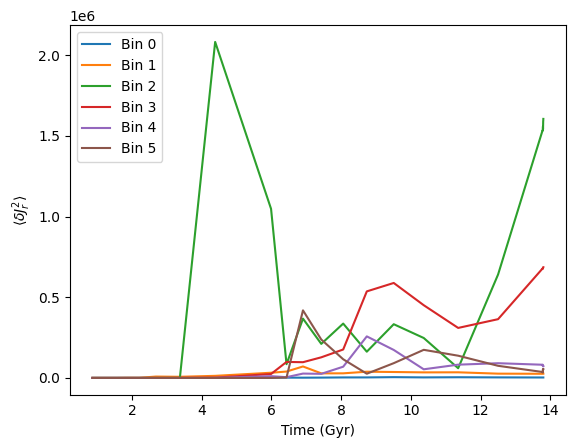

In [569]:
var_dict = {
    "et_norm": {"abs_label": r"\Delta e", "rel_label": r"\delta e"},
    "jr": {"abs_label": r"\Delta J_{r}", "rel_label": r"\delta J_{r}"},
    "jp": {"abs_label": r"\Delta J_{p}", "rel_label": r"\delta J_{p}"},
    "jz": {"abs_label": r"\Delta J_{z}", "rel_label": r"\delta J_{z}"},
}

# SETTINGS
plot_type = "rel"
square = True
cmap = "viridis"

ylabel = var_dict[var][plot_type + "_label"]
if square:
    ylabel = ylabel + "^2"
ylabel = r"$\langle " + ylabel + r" \rangle$"

# colors = cmap(np.linspace(0, 1, len(tform_bin_cnts.keys())))
for tform_bin in tform_bin_cnts.keys():
    bin_cnt = tform_bin_cnts[tform_bin]
    d_hold = np.zeros((bin_cnt, len(time_lst)))

    k = 0
    for it_id in it_dict.keys():
        for gcid in it_dict[it_id].keys():
            if it_dict[it_id][gcid]["tform_grp"] == tform_bin:
                f_term = it_dict[it_id][gcid]["first_term"]
                l_term = it_dict[it_id][gcid]["last_term"]
                for j in range(f_term, l_term):
                    d_abs = np.abs(it_dict[it_id][gcid][var][j + 1] - it_dict[it_id][gcid][var][f_term])
                    if plot_type == "abs":
                        d_var = d_abs
                    else:
                        d_var = d_abs / np.abs(it_dict[it_id][gcid][var][f_term])

                    if square:
                        d_var = d_var**2

                    d_hold[k, j + 1] = d_var

                k += 1

    plot_var = np.mean(d_hold, axis=0)
    # plot_var = np.mean(d_hold, axis=0)
    plt.plot(time_lst, plot_var, label="Bin " + str(tform_bin))

plt.xlabel("Time (Gyr)")
plt.ylabel(ylabel)

plt.legend()

In [570]:
def linear_region(x, y, r_thresh=0.95, p_thresh=0.05, int_limit=0.05):
    idx_lim = 1
    lin_stats_true = 0
    time_rng = 0

    for rng in range(2, len(x)):
        lin_stats = stats.linregress(x[:rng], y[:rng])
        # if lin_stats.rvalue >= r_thresh:
        # if (lin_stats.rvalue >= r_thresh) & (lin_stats.pvalue <= p_thresh):
        if (
            (lin_stats.rvalue >= r_thresh)
            & (lin_stats.pvalue <= p_thresh)
            & (np.abs(lin_stats.intercept) <= int_limit)
        ):
            idx_lim = rng
            lin_stats_true = lin_stats
            time_rng = x[rng]

    return lin_stats_true, time_rng, idx_lim

Bin 0: y = 0.57x + 0.01, R^2 = 1.0, p = 0.02, dt = 1.43
Bin 1: y = 0.08x + 0.05, R^2 = 0.97, p = 0.0001, dt = 5.36
Bin 2: y = 0.25x + 0.04, R^2 = 0.99, p = 0.0018, dt = 2.73
Bin 3: y = 0.29x + 0.05, R^2 = 0.97, p = 0.035, dt = 2.06
Bin 4: y = 0.64x + 0.01, R^2 = 1.0, p = 0.0, dt = 0.9
Bin 5: y = 1.03x + 0.01, R^2 = 1.0, p = 0.0, dt = 0.9


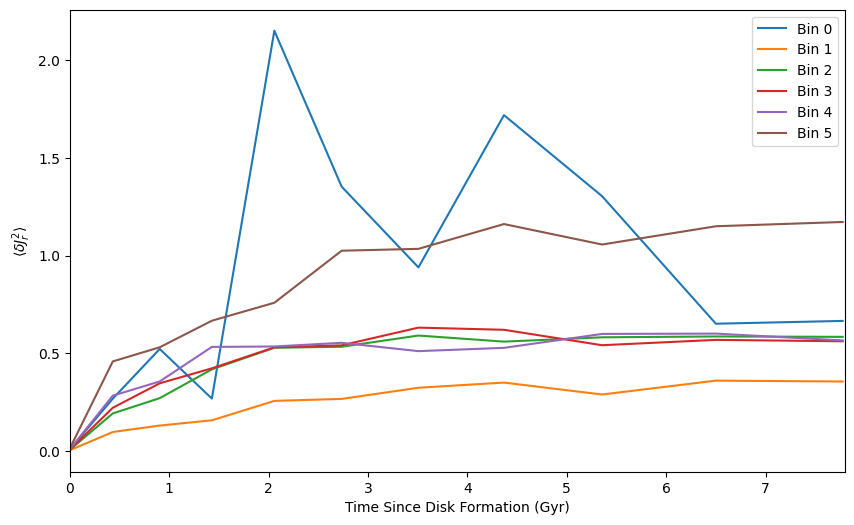

In [ ]:
plot_dis_lin = False

plt.figure(figsize=(10, 6))

var_dict = {
    "et_norm": {"abs_label": r"\Delta e", "rel_label": r"\delta e"},
    "jr": {"abs_label": r"\Delta J_{r}", "rel_label": r"\delta J_{r}"},
    "jp": {"abs_label": r"\Delta J_{p}", "rel_label": r"\delta J_{p}"},
    "jz": {"abs_label": r"\Delta J_{z}", "rel_label": r"\delta J_{z}"},
}

# SETTINGS
plot_type = "rel"
square = True
cmap = "viridis"

ylabel = var_dict[var][plot_type + "_label"]
if square:
    ylabel = ylabel + "^2"
ylabel = r"$\langle " + ylabel + r" \rangle$"

trim_end = -10
disk_time = time_lst[time_lst >= disk_form]
disk_time = np.insert(disk_time, 0, np.max(time_lst[time_lst < disk_form]))
plot_time = disk_time - disk_form

# colors = cmap(np.linspace(0, 1, len(tform_bin_cnts.keys())))
# bin_var_disk = {tform_bin: [] for tform_bin in tform_bin_cnts.keys()}
# bin_var_disk["time"] = plot_time[:trim_end]

for tform_bin in tform_bin_cnts.keys():
    bin_cnt = tform_bin_cnts[tform_bin]
    d_hold = np.zeros((bin_cnt, len(disk_time)))

    k = 0
    for it_id in it_dict.keys():
        for gcid in it_dict[it_id].keys():
            if it_dict[it_id][gcid]["tform_grp"] == tform_bin:
                f_term = len(time_lst) - len(disk_time)
                l_term = it_dict[it_id][gcid]["last_term"]

                for j in range(f_term, l_term + 1):
                    d_abs = np.abs(it_dict[it_id][gcid][var][j] - it_dict[it_id][gcid][var][f_term])
                    if plot_type == "abs":
                        d_var = d_abs
                    else:
                        d_var = d_abs / np.abs(it_dict[it_id][gcid][var][f_term])

                    if square:
                        d_var = d_var**2

                    d_hold[k, j - f_term] = d_var

                k += 1

    # plot_var = np.apply_along_axis(biweight_location, 0, d_hold)
    plot_var = np.apply_along_axis(lambda x: biweight_location(x, c=4.0), 0, d_hold)

    # trim_end = -10
    # x_trim = plot_time[:-trim_end]
    # y_trim = plot_var[:-trim_end]

    # fine_time = np.linspace(x_trim[0], x_trim[-1], 10 * len(x_trim))
    # interp_func = interp1d(x_trim, y_trim, kind="linear")
    # plot_var_fine = interp_func(fine_time)
    # plot_var_smooth = gaussian_filter1d(plot_var_fine, sigma=3)
    # plot_var_smooth[0] = 0

    plt.plot(plot_time[:trim_end], plot_var[:trim_end], label="Bin " + str(tform_bin))
    # plt.plot(fine_time, plot_var_smooth, label="Bin " + str(tform_bin))
    # bin_var_disk[tform_bin] = plot_var[:trim_end]

    lin_stats, time_rng, idx_lim = linear_region(plot_time[:trim_end], plot_var[:trim_end])

    if plot_dis_lin:
        x = plot_time[:idx_lim]
        y = lin_stats.slope * x + lin_stats.intercept
        plt.plot(x, y, ls="--")

    print(
        "Bin",
        str(tform_bin) + ":",
        "y =",
        str(np.round(lin_stats.slope, 2)) + "x",
        "+",
        str(np.round(lin_stats.intercept, 2)) + ",",
        "R^2 = " + str(np.round(lin_stats.rvalue, 2)) + ",",
        "p = " + str(np.round(lin_stats.pvalue, 4)) + ",",
        "dt = " + str(np.round(time_rng, 2)),
    )

plt.xlabel("Time Since Disk Formation (Gyr)")
plt.ylabel(ylabel)

plt.xlim(0, np.max(plot_time))

plt.legend()

In jr we see an uptick around 2Gyr (post disk form) which could be related to merger pericentre that is happenign then